# Verificación Numérica de la Segunda Ley de Kepler mediante Simulaciones de N-Cuerpos

**Presentado por:** Eduardo Pérez Cárdenas

## 1. Introducción y Modelo Físico

#### Segunda Ley de Kepler:
- El radio vector que une a un planeta con el Sol barre áreas iguales en tiempos iguales. 
- Consecuencia de la conservación del momento angular bajo una fuerza central pura.

#### De la segunda ley Newton y la ley de gravitación universal de Newton (doble ciclo for):

$$ \frac{d^2\vec{r}_i}{dt^2} = - \sum_{j \neq i}^{N} G m_j \frac{\vec{r}_i - \vec{r}_j}{|\vec{r}_i - \vec{r}_j|^3} $$

Para resolver esta ecuación diferencial de segundo orden computacionalmente, la reducimos a un sistema de ecuaciones de primer orden y utilizamos el método numérico de **diferencias finitas**.

#### Análisis hecho en 2D

#### Unidades y cantidades:
- G = $6.67 \times 10^{-11}$ y masa del Sol (kg) = $2 \times 10^{30}$.
- Los números tan inmensos o minúsculos le causan problemas de precisión a la computadora (errores de punto flotante). Para evitarlo: "sistema de unidades astronómicas":
- Masa = Masas solares (El sol vale 1.0).
- Distancia = Unidad Astronómica (La Tierra está a 1.0).
- Tiempo = Años.

Bajo este sistema maravillosamente simple, la matemática dicta que $G$ equivale exactamente a $4\pi^2$.

In [ ]:
import math
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

#Para no mostrar "warnings"
import warnings
warnings.filterwarnings("ignore")

#Sistema normalizado: Masas Solares, Unidades Astronómicas (AU), y Años.
G = 4.0 * math.pi**2

#### Diferencias finitas:

In [2]:
def calcular_aceleraciones(masas, posiciones):
    """ Calcula las aceleraciones (ax, ay) para N cuerpos usando la Ley de Gravedad """
    N = len(masas)
    aceleraciones = [[0.0, 0.0] for _ in range(N)]
    
    for i in range(N):
        ax, ay = 0.0, 0.0
        for j in range(N):
            if i != j:
                dx = posiciones[j][0] - posiciones[i][0]
                dy = posiciones[j][1] - posiciones[i][1]
                dist_sq = dx**2 + dy**2
                dist = math.sqrt(dist_sq)
                
                # Suavizado (softening) para evitar la división por cero (Floating Point Exception)
                epsilon = 1e-9 
                fuerza_mag = (G * masas[j]) / (dist_sq + epsilon)
                
                # Descomposición vectorial
                ax += fuerza_mag * (dx / dist)
                ay += fuerza_mag * (dy / dist)
        aceleraciones[i] = [ax, ay]
    return aceleraciones

def paso_diferencias_finitas(masas, posiciones, velocidades, dt):
    """ Avanza el sistema un paso de tiempo dt usando Euler Semi-Implícito """
    N = len(masas)
    aceleraciones = calcular_aceleraciones(masas, posiciones)
    
    for i in range(N):
        # 1. Actualizamos velocidades (Diferencia hacia adelante)
        velocidades[i][0] += aceleraciones[i][0] * dt
        velocidades[i][1] += aceleraciones[i][1] * dt
        
        # 2. Actualizamos posiciones usando la nueva velocidad
        posiciones[i][0] += velocidades[i][0] * dt
        posiciones[i][1] += velocidades[i][1] * dt
        
    return posiciones, velocidades

### Simulación y Animación a 2 Cuerpos

In [4]:
# 1. Condiciones Iniciales: para forzar una elipse notoria
masas_2c = [1.0, 3e-6] 
posiciones_2c = [[0.0, 0.0], [1.0, 0.0]] 
velocidades_2c = [[0.0, 0.0], [0.0, 4.0]] 

# 2. Parámetros de la simulación
dt = 0.0005 
pasos_totales = 4000 

historial_t = []
historial_x_planeta = []
historial_y_planeta = []
historial_vx_planeta = []
historial_vy_planeta = []
tiempo_actual = 0.0

# 3. Bucle Principal de Simulación
for paso in range(pasos_totales):
    historial_t.append(tiempo_actual)
    historial_x_planeta.append(posiciones_2c[1][0])
    historial_y_planeta.append(posiciones_2c[1][1])
    historial_vx_planeta.append(velocidades_2c[1][0])
    historial_vy_planeta.append(velocidades_2c[1][1])
    
    posiciones_2c, velocidades_2c = paso_diferencias_finitas(masas_2c, posiciones_2c, velocidades_2c, dt)
    tiempo_actual += dt

# 4. Generación de la Animación (Omito el bloque de plot por brevedad, es el mismo de arriba)
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.set_aspect('equal')
ax.grid(True, linestyle='--', alpha=0.6)
ax.set_title("Animación: Órbita Ideal a 2 Cuerpos")
ax.set_xlabel("X (AU)")
ax.set_ylabel("Y (AU)")

# Elementos gráficos
sol, = ax.plot([0], [0], 'yo', markersize=18, markeredgecolor='orange', label='Sol')
planeta, = ax.plot([], [], 'bo', markersize=8, label='Planeta')
traza, = ax.plot([], [], 'b-', alpha=0.4)
ax.legend()

def init():
    planeta.set_data([], [])
    traza.set_data([], [])
    return planeta, traza

def update(frame):
    planeta.set_data([historial_x_planeta[frame]], [historial_y_planeta[frame]])
    traza.set_data(historial_x_planeta[:frame], historial_y_planeta[:frame])
    return planeta, traza

# Creamos la animación (renderizamos 1 de cada 40 frames para que corra fluido y rápido)
ani = FuncAnimation(fig, update, frames=range(0, pasos_totales, 40),
                    init_func=init, blit=True, interval=30)

plt.close() # Cierra el plot estático para que solo se muestre el video HTML
HTML(ani.to_jshtml())

## 2. Midiendo a Kepler: Integración Numérica e Interpolación

Para verificar la Segunda Ley de Kepler, debemos calcular el área barrida por el vector de posición del planeta. La ley establece que el planeta barre áreas iguales en tiempos iguales. La tasa de cambio de esta área en el tiempo se conoce en física como 
velocidad areolar.

Geométricamente, en un intervalo de tiempo infinitesimal $dt$, el planeta se mueve una distancia $d\vec{r} = \vec{v}dt$. El área barrida $dA$ corresponde al área del triángulo formado por el vector de posición $\vec{r}$ y el vector de desplazamiento $d\vec{r}$. El área de un triángulo definido por dos vectores es la mitad de la magnitud de su producto cruz:

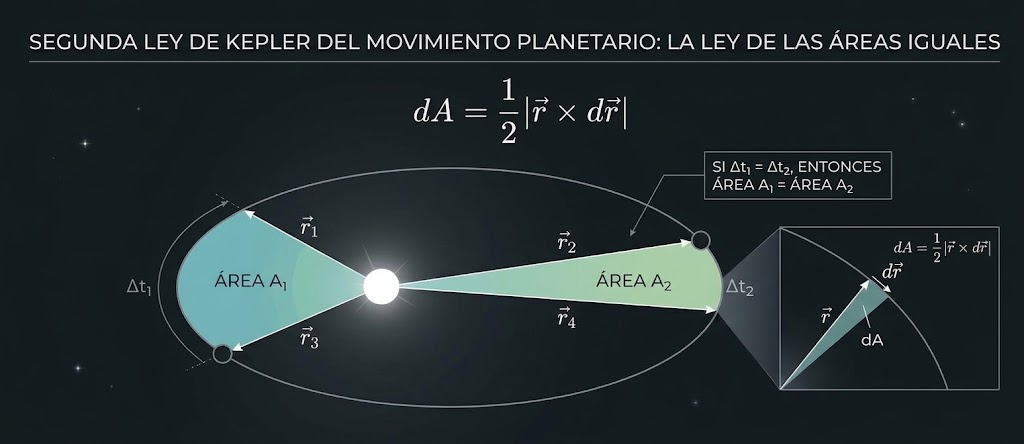

$$dA = \frac{1}{2} |\vec{r} \times d\vec{r}|$$

Si dividimos ambos lados entre el diferencial de tiempo $dt$, obtenemos la velocidad areolar:

$$\frac{dA}{dt} = \frac{1}{2} \left|\vec{r} \times \frac{d\vec{r}}{dt}\right| = \frac{1}{2} |\vec{r} \times \vec{v}|$$

En nuestra simulación (que ocurre en el plano cartesiano 2D), el vector de posición es $\vec{r} = (x, y)$ y el vector de velocidad es $\vec{v} = (v_x, v_y)$. Al resolver la magnitud del producto cruz para estos vectores bidimensionales, la expresión matemática se convierte directamente en:

$$\frac{dA}{dt} = \frac{1}{2} (x \cdot v_y - y \cdot v_x)$$

Dado que nuestra simulación nos entrega datos discretos en intervalos de tiempo $h = \Delta t$, utilizaremos la **Regla de Simpson de 1/3 compuesta** para integrar esta función y obtener el área total barrida. Este método aproxima el integrando mediante un polinomio de segundo orden, ofreciendo una alta precisión para nuestra malla temporal.

Adicionalmente, si deseamos evaluar la posición exacta del planeta en un instante de tiempo arbitrario que no coincida con nuestro paso discreto $\Delta t$, implementaremos la **Interpolación de diferencias divididas de Newton**.

In [5]:
def simpson_un_tercio_compuesta(f_valores, h):
    n = len(f_valores) - 1
    
    if n % 2 != 0:
        f_valores = f_valores[:-1]
        n -= 1
        
    suma = f_valores[0] + f_valores[-1]
    
    for i in range(1, n):
        if i % 2 == 0:
            suma += 2 * f_valores[i] 
        else:
            suma += 4 * f_valores[i] 
            
    return (h / 3.0) * suma

def diferencias_divididas_coef(x_datos, y_datos):
    n = len(x_datos)
    tabla = [[0.0 for _ in range(n)] for _ in range(n)]
    
    for i in range(n):
        tabla[i][0] = y_datos[i]
        
    for j in range(1, n):
        for i in range(n - j):
            tabla[i][j] = (tabla[i+1][j-1] - tabla[i][j-1]) / (x_datos[i+j] - x_datos[i])
            
    return tabla[0]

def evaluar_newton(x_datos, coef, x_eval):
    n = len(coef)
    resultado = coef[n-1]
    
    for k in range(n-2, -1, -1):
        resultado = resultado * (x_eval - x_datos[k]) + coef[k]
        
    return resultado

In [6]:
# 1. Calculamos la función a integrar: velocidad areolar f(t) = 0.5 * (x*vy - y*vx)
velocidad_areolar = []
for i in range(pasos_totales):
    x = historial_x_planeta[i]
    y = historial_y_planeta[i]
    vx = historial_vx_planeta[i]
    vy = historial_vy_planeta[i]
    
    dA_dt = 0.5 * (x * vy - y * vx)
    velocidad_areolar.append(dA_dt)

# 2. Seleccionamos el intervalo en el Periastro (cerca al sol)
inicio_periastro = 0
fin_periastro = 200  
f_periastro = velocidad_areolar[inicio_periastro:fin_periastro+1]

# 3. Seleccionamos un intervalo idéntico en el Apoastro (lejos del sol)
indice_apoastro = pasos_totales // 2
inicio_apoastro = indice_apoastro - 100
fin_apoastro = indice_apoastro + 100
f_apoastro = velocidad_areolar[inicio_apoastro:fin_apoastro+1]

# 4. Integramos usando nuestra función de Simpson 1/3
area_periastro = simpson_un_tercio_compuesta(f_periastro, dt)
area_apoastro = simpson_un_tercio_compuesta(f_apoastro, dt)

print(f"Área barrida en el Periastro (0.1 años): {area_periastro:.6f} UA²")
print(f"Área barrida en el Apoastro  (0.1 años): {area_apoastro:.6f} UA²")

Área barrida en el Periastro (0.1 años): 0.200000 UA²
Área barrida en el Apoastro  (0.1 años): 0.200000 UA²


In [7]:
# Análisis de Error
error_absoluto = abs(area_periastro - area_apoastro)
error_relativo_porcentual = (error_absoluto / area_periastro) * 100.0

print("--- ANÁLISIS DE ERROR ---")
print(f"Error absoluto: {error_absoluto:.8e} UA²")
print(f"Error Relativo Aproximado: {error_relativo_porcentual:.8f} %")

if error_relativo_porcentual < 0.1:
    print("Conclusión: La Segunda Ley de Kepler se verifica con éxito.")

--- ANÁLISIS DE ERROR ---
Error absoluto: 1.64605724e-07 UA²
Error Relativo Aproximado: 0.00008230 %
Conclusión: La Segunda Ley de Kepler se verifica con éxito.
